**학습 목표**: 상위 k개 특이값만으로 이미지를 재구성해, "특이값이 큰 순서 = 중요한 정보 순서"라는 직관을 시각적으로 검증한다.

In [17]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt

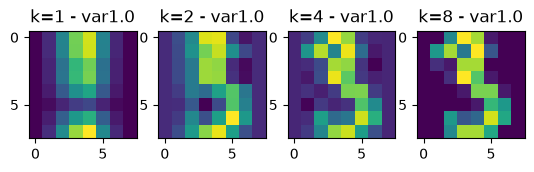

np.float64(1.0)

In [27]:
def svd_image_reconstruction(img: np.ndarray, k_values: list[int] = [1, 2, 4, 8]):
    """
    요구사항:
    - digits.images[0] 같은 8x8 이미지 1장에 np.linalg.svd를 적용한다.
    - 각 k에 대해 U[:, :k] @ diag(S[:k]) @ Vt[:k, :]로 재구성한다.
    - 각 재구성이 설명하는 분산 비율((S[:k]**2).sum() / (S**2).sum())을 계산한다.
    - matplotlib으로 k별 재구성 이미지를 나란히 그려 week04/svd_image_compression.png로 저장한다.
    """
    results = []
    var_po = []
    for k in k_values:
        u, s, v = np.linalg.svd(img)
        u = u[:,:k]
        s = s[:k]
        v = v[:k,:]
        result = u@np.diag(s)@v
        results.append(result)
        var = (s[:k]**2).sum()/((s**2).sum())
        var_po.append(var)
    
    for i in range(len(k_values)):
        plt.subplot(1,4,i+1)
        plt.title(f"k={k_values[i]} - var{var_po[i]}")
        plt.imshow(results[i])
        
    plt.show()
    return var
data = load_digits()
svd_image_reconstruction(data.images[3])